# Multichannel Tryout for 488

In [6]:
from __future__ import annotations
import time
import tkinter
import pathlib
import pickle
import tifffile
import os
import numpy as np
from PIL import (Image, ImageTk, ImageDraw)
from tkinter import filedialog, messagebox
from matplotlib.figure import Figure 
from matplotlib.backends.backend_tkagg import (FigureCanvasTkAgg, NavigationToolbar2Tk)
from matplotlib.patches import Rectangle, Circle
from matplotlib.backend_bases import MouseEvent
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib.pyplot as plt
from skimage import measure
import fishCore
import fishGUI
import threading
import concurrent.futures
import cv2
import imageio.v3 as iio
import napari
from aicsimageio import AICSImage

f = fishCore.Fish(pathlib.Path("./config.ini"))
f.set_model_version("3.50")

c:\Users\msgal\Downloads\Ding_Lab\FISH-ML\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


final text_encoder_type: bert-base-uncased


[2025-08-06 15:50:14,459][INFO] CHECK: Model version 3.50 loaded


In [ ]:
def helper__hdr2Rgb(hdr_image: np.ndarray, dynamic_range: int) -> np.ndarray:
        scale_factor = 255 / dynamic_range # 65536
        scaled_image = (hdr_image * scale_factor).astype(np.uint8)
        rgb_image = np.stack((scaled_image,) * 3, axis=-1)
        return rgb_image

def helper__hdr2RgbNorm(hdr_image: np.ndarray, brightness_factor: int) -> np.ndarray:
        img_normalized = cv2.normalize(hdr_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        img_rgb = cv2.cvtColor(img_normalized, cv2.COLOR_GRAY2RGB)
        return np.clip(img_rgb * brightness_factor, 0, 255).astype(np.uint8)

Image shape: (3, 2048, 2048)


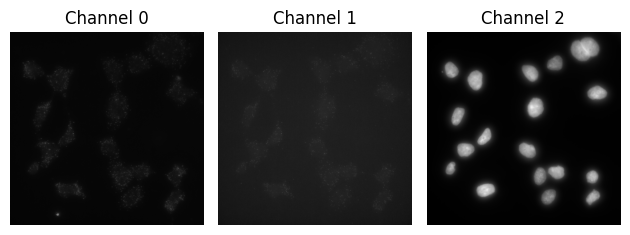

In [7]:
import tifffile
import matplotlib.pyplot as plt

img_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/Composite Images (Multi-Channel)/488_pb5sp5_s5.composite.tif"
img = tifffile.imread(img_path)

print(f"Image shape: {img.shape}")

if img.ndim == 3 or img.ndim == 2:
    num_channels = img.shape[0]
    for i in range(num_channels):
        plt.subplot(1, num_channels, i + 1)
        plt.imshow(img[i], cmap="gray")
        plt.title(f"Channel {i}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    # Single channel
    plt.imshow(img, cmap="gray")
    plt.title("Single Channel")
    plt.axis("off")
    plt.show()


Estimated Gaussian noise standard deviation = 4.061706919627111
Estimated Gaussian noise standard deviation = 18.033917976562705


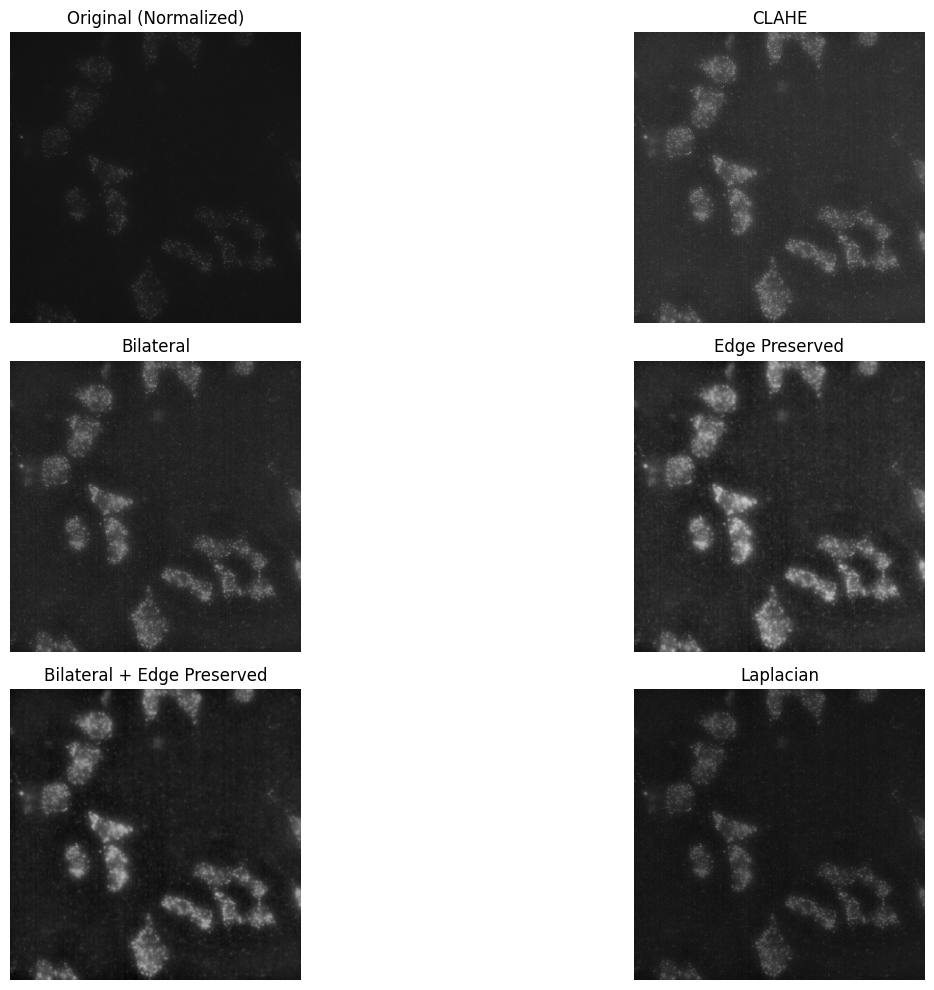

In [53]:
import cv2
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from skimage import filters, morphology, measure, segmentation
from scipy import ndimage as ndi
import pathlib
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
)

# --------------------------------------
# Helper functions
# --------------------------------------

def normalize_to_uint8(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def clahe(img, clip_limit=4.0, tile_size=(8,8)):
    c = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return c.apply(img)

def gradient(channel, ksize=5):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    return cv2.morphologyEx(channel, cv2.MORPH_GRADIENT, kernel)

# --------------------------------------
# Load image and preprocess
# --------------------------------------

image_path = pathlib.Path("C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/data_an_STACKED/AD_20_A2_3_STACKED.tif")

with tifffile.TiffFile(image_path) as tif:
    ch = tif.pages[0].asarray() # testing with 488
    nucleus = tif.pages[1].asarray()

ch = normalize_to_uint8(ch)

# ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
sigma_est = estimate_sigma(ch, channel_axis=-1, average_sigmas=True)
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

clahe = clahe(ch)
grad = gradient(clahe)

# ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
sigma_est = estimate_sigma(clahe, channel_axis=-1, average_sigmas=True)
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

sigma_norm = sigma_est + 3.0
sigma_weak = sigma_est - 10.0

bilat1 = cv2.bilateralFilter(clahe, d=9, sigmaColor=sigma_norm, sigmaSpace=15, borderType=cv2.BORDER_REFLECT_101)
edge_preserved = cv2.edgePreservingFilter(clahe, flags=1, sigma_s=sigma_norm, sigma_r=0.4)

bilat_edge = cv2.edgePreservingFilter(bilat1, flags=1, sigma_s=sigma_weak, sigma_r=0.4)

laplacian = cv2.Laplacian(ch, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)
blended = cv2.addWeighted(bilat1, 0.7, laplacian, 0.3, 0)

# --------------------------------------
# Visualization
# --------------------------------------
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(16, 10), sharex=True, sharey=True)

ax[0, 0].imshow(ch, cmap='gray')
ax[0, 0].set_title("Original (Normalized)")
ax[0, 0].axis('off')

ax[0, 1].imshow(clahe, cmap='gray')
ax[0, 1].set_title("CLAHE")
ax[0, 1].axis('off')


ax[1, 0].imshow(bilat1, cmap='gray')
ax[1, 0].set_title("Bilateral")
ax[1, 0].axis('off')

ax[1, 1].imshow(edge_preserved, cmap='gray')
ax[1, 1].set_title("Edge Preserved")
ax[1, 1].axis('off')

ax[2, 0].imshow(bilat_edge, cmap='gray')
ax[2, 0].set_title("Bilateral + Edge Preserved")
ax[2, 0].axis('off')

ax[2, 1].imshow(blended, cmap='gray')
ax[2, 1].set_title("Laplacian")
ax[2, 1].axis('off')


fig.tight_layout()

plt.show()

## Testing Filters w/ Watershed Segmentation

Estimated Gaussian noise standard deviation = 1.7238518729698984
Estimated Gaussian noise standard deviation = 7.698263550937639


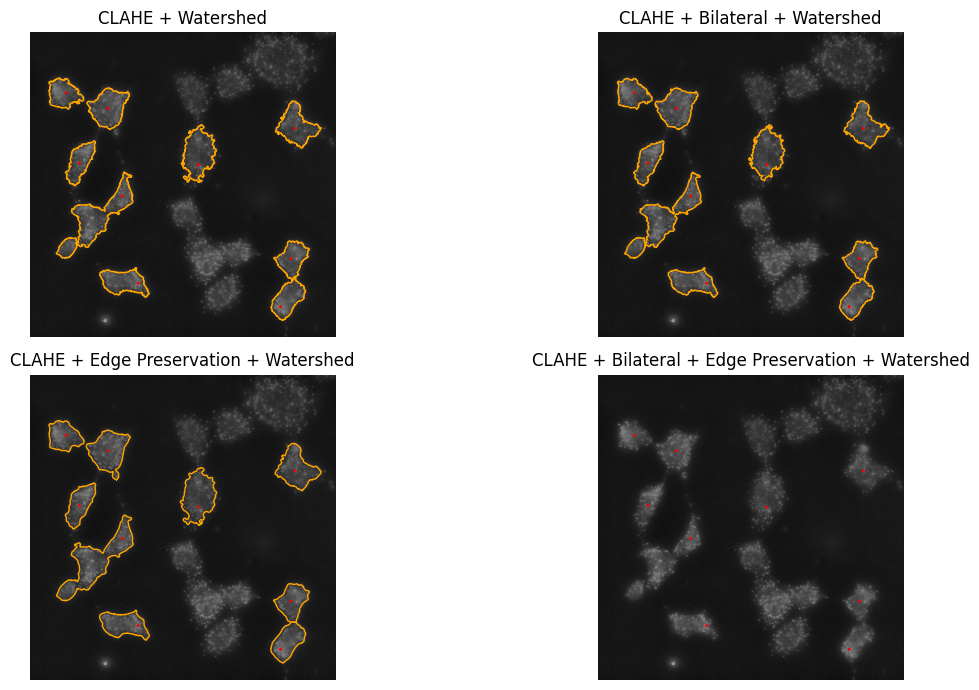

In [35]:
import cv2
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from skimage import filters, morphology, measure, segmentation
from scipy import ndimage as ndi
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
)
import pathlib

# --------------------------------------
# Helper functions
# --------------------------------------

def normalize_to_uint8(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def clahe_filter(img, clip_limit=4.0, tile_size=(8,8)):
    c = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return c.apply(img)

def postproc_mask(m):
    m = morphology.remove_small_objects(m.astype(bool), min_size=200)
    m = morphology.binary_opening(m, footprint=morphology.disk(2))
    return m.astype(np.uint8)

def watershed_segment(cyt_img: np.ndarray,
                      centers: list[tuple[float,float]],
                      thresh_method: str = "otsu",
                      min_size: int = 300) -> list[np.ndarray]:
    if thresh_method == "otsu":
        thresh = filters.threshold_otsu(cyt_img)
    else:
        thresh = np.percentile(cyt_img, 30)
    
    binary = cyt_img > thresh
    binary = morphology.remove_small_holes(binary, area_threshold=1000)
    binary = morphology.remove_small_objects(binary, min_size=1000)

    dist = ndi.distance_transform_edt(binary)

    markers = np.zeros(cyt_img.shape, dtype=np.int32)
    for idx, (cx, cy) in enumerate(centers, start=1):
        xi, yi = int(round(cx)), int(round(cy))
        if 0 <= yi < cyt_img.shape[0] and 0 <= xi < cyt_img.shape[1]:
            markers[yi, xi] = idx

    labels = segmentation.watershed(-dist, markers, mask=binary)

    masks = []
    for i in range(1, len(centers)+1):
        cell = (labels == i)
        cell = postproc_mask(cell)
        masks.append(cell)
    return masks

# --------------------------------------
# Load image and preprocess
# --------------------------------------

image_path = pathlib.Path("C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/Composite Images (Multi-Channel)/488_pb5sp5_s5.composite.tif")

with tifffile.TiffFile(image_path) as tif:
    ch = tif.pages[0].asarray() # testing with 488
    nucleus = tif.pages[1].asarray()

ch = normalize_to_uint8(ch)

# ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
sigma_est = estimate_sigma(ch, channel_axis=-1, average_sigmas=True)
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

clahe = clahe_filter(ch)
# grad = gradient(clahe)

# ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
sigma_est = estimate_sigma(clahe, channel_axis=-1, average_sigmas=True)
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

sigma_norm = sigma_est + 3.0
sigma_weak = sigma_est - 10.0

bilat1 = cv2.bilateralFilter(clahe, d=9, sigmaColor=sigma_norm, sigmaSpace=sigma_norm, borderType=cv2.BORDER_REFLECT_101)
edge_preserved = cv2.edgePreservingFilter(clahe, flags=1, sigma_s=sigma_norm, sigma_r=0.4)

bilat_edge = cv2.edgePreservingFilter(bilat1, flags=1, sigma_s=sigma_weak, sigma_r=0.4)

laplacian = cv2.Laplacian(ch, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)
blended = cv2.addWeighted(bilat1, 0.8, laplacian, 0.2, 0)

# ----- BBoxes and Masks -----
bbox_nucleus = f.AppIntDINOwrapper(nucleus) 
centers = [((x1 + x2) / 2, (y1 + y2) / 2) for x1, y1, x2, y2 in bbox_nucleus]

masks_clahe = watershed_segment(clahe, centers)
# masks_grad = watershed_segment(grad, centers)
masks_bilat = watershed_segment(bilat1, centers)
masks_edge_preserved = watershed_segment(edge_preserved, centers)
masks_bilat_edge = watershed_segment(bilat_edge, centers)

# --------------------------------------
# Visualization
# --------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

### ALL HAVE WATERSHED 


# CLAHE filter only
axes[0, 0].imshow(clahe, cmap='gray')
axes[0, 0].set_title("CLAHE + Watershed")
axes[0, 0].axis('off')
for mask in masks_clahe:
    for contour in measure.find_contours(mask, 0.5):
        axes[0, 0].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')
for cx, cy in centers:
    axes[0, 0].add_patch(Circle((cx, cy), radius=5, color='red', fill=True))

# CLAHE + Bilateral 
axes[0, 1].imshow(clahe, cmap='gray')
axes[0, 1].set_title("CLAHE + Bilateral + Watershed")
axes[0, 1].axis('off')
for mask in masks_bilat:
    for contour in measure.find_contours(mask, 0.5):
        axes[0, 1].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')
for cx, cy in centers:
    axes[0, 1].add_patch(Circle((cx, cy), radius=5, color='red', fill=True))

# CLAHE + Edge Preservation
axes[1, 0].imshow(clahe, cmap='gray')
axes[1, 0].set_title("CLAHE + Edge Preservation + Watershed")
axes[1, 0].axis('off')
for mask in masks_edge_preserved:
    for contour in measure.find_contours(mask, 0.5):
        axes[1, 0].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')
for cx, cy in centers:
    axes[1, 0].add_patch(Circle((cx, cy), radius=5, color='red', fill=True))

# CLAHE + Bilateral + Edge Preservation
axes[1, 1].imshow(clahe, cmap='gray')
axes[1, 1].set_title("CLAHE + Bilateral + Edge Preservation + Watershed")
axes[1, 1].axis('off')
for mask in masks_bilat_edge:
    for contour in measure.find_contours(mask, 0.5):
        axes[1, 1].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')
for cx, cy in centers:
    axes[1, 1].add_patch(Circle((cx, cy), radius=5, color='red', fill=True))

plt.tight_layout()
plt.show()

## Testing w/ Filters + Watershed-Guided Sam

Estimated Gaussian noise standard deviation = 4.061706919627111
Estimated Gaussian noise standard deviation = 21.364847934154533


[CYTO] Starting prediction for 14 cells
[CYTO] Input image shape: (2048, 2048, 3), dtype: uint8
[CYTO] Using pre-formatted 3-channel image as RGB
[CYTO] Cell 0: box=[458.0, 165.0, 727.0, 361.0], point=[592.5, 263.0]
[CYTO] Cell 1: box=[393.0, 374.0, 649.0, 679.0], point=[521.0, 526.5]
[CYTO] Cell 2: box=[215.0, 658.0, 427.0, 887.0], point=[321.0, 772.5]
[CYTO] Cell 3: box=[549.0, 861.0, 869.0, 1093.0], point=[709.0, 977.0]
[CYTO] Cell 4: box=[1062.0, 1453.0, 1301.0, 1597.0], point=[1181.5, 1525.0]
[CYTO] Cell 5: box=[384.0, 1087.0, 559.0, 1338.0], point=[471.5, 1212.5]
[CYTO] Cell 6: box=[1288.0, 1224.0, 1561.0, 1391.0], point=[1424.5, 1307.5]
[CYTO] Cell 7: box=[1560.0, 1251.0, 1814.0, 1494.0], point=[1687.0, 1372.5]
[CYTO] Cell 8: box=[656.0, 1091.0, 843.0, 1433.0], point=[749.5, 1262.0]
[CYTO] Cell 9: box=[1429.0, 1392.0, 1667.0, 1672.0], point=[1548.0, 1532.0]
[CYTO] Cell 10: box=[1662.0, 1494.0, 1868.0, 1692.0], point=[1765.0, 1593.0]
[CYTO] Cell 11: box=[1263.0, 1530.0, 1433.0, 1

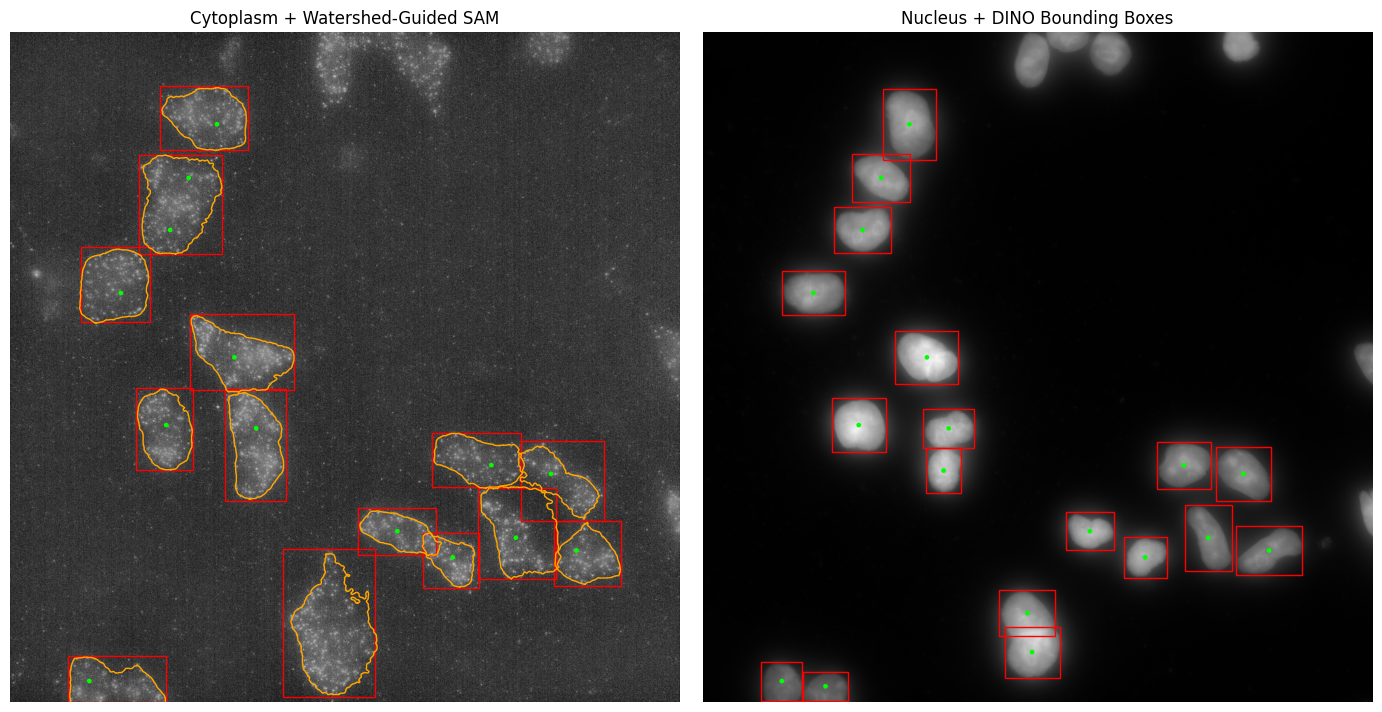

In [ ]:
import cv2
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from skimage import filters, morphology, measure, segmentation
from scipy import ndimage as ndi
import pathlib

# --------------------------------------
# Helper functions
# --------------------------------------

def normalize_to_uint8(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def clahe_filter(img, clip_limit=5.0, tile_size=(8,8)):
    c = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return c.apply(img)

def postproc_mask(m):
    m = morphology.remove_small_objects(m.astype(bool), min_size=200)
    m = morphology.binary_closing(m, footprint=morphology.disk(3))
    m = morphology.binary_opening(m, footprint=morphology.disk(2))
    return m.astype(np.uint8)

def mask_to_bbox(mask):
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return (xs.min(), ys.min(), xs.max(), ys.max())

def watershed_segment_with_centers(cyt_img, centers):
    thresh = filters.threshold_otsu(cyt_img)
    binary = cyt_img > thresh
    binary = morphology.remove_small_holes(binary, area_threshold=1000)
    # binary = morphology.remove_small_objects(binary, min_size=1000)
    dist = ndi.distance_transform_edt(binary)

    markers = np.zeros(cyt_img.shape, dtype=np.int32)
    for i, (cx, cy) in enumerate(centers, start=1):
        xi, yi = int(round(cx)), int(round(cy))
        if 0 <= yi < cyt_img.shape[0] and 0 <= xi < cyt_img.shape[1]:
            markers[yi, xi] = i

    edges = filters.sobel(cyt_img)
    elevation = -dist + 5 * edges
    labels = segmentation.watershed(elevation, markers=markers, mask=binary)

    masks = []
    for i in range(1, np.max(labels)+1):
        mask = (labels == i)
        if np.sum(mask) > 0:
            masks.append(postproc_mask(mask))
    return masks

# --------------------------------------
# Load image and preprocess
# --------------------------------------

image_path = pathlib.Path("C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/data_an_STACKED/AD_20_A2_3_STACKED.tif")

with tifffile.TiffFile(image_path) as tif:
    ch = tif.pages[0].asarray() # testing with 488
    nucleus = tif.pages[1].asarray()

ch = normalize_to_uint8(ch)

# ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
sigma_est = estimate_sigma(ch, channel_axis=-1, average_sigmas=True)
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

cyt_clahe = clahe_filter(ch)
cyt_grad = gradient(clahe)

# ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
sigma_est = estimate_sigma(cyt_clahe, channel_axis=-1, average_sigmas=True)
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

sigma_norm = sigma_est + 3.0
sigma_weak = sigma_est - 10.0

cyt_bilat = cv2.bilateralFilter(cyt_clahe, d=9, sigmaColor=sigma_norm, sigmaSpace=15, borderType=cv2.BORDER_REFLECT_101)
cyt_edge_preserved = cv2.edgePreservingFilter(cyt_clahe, flags=1, sigma_s=sigma_norm, sigma_r=0.4)
cyt_bilat_edge = cv2.edgePreservingFilter(cyt_bilat, flags=1, sigma_s=sigma_weak, sigma_r=0.4)

laplacian = cv2.Laplacian(ch, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)
cyt_blended = cv2.addWeighted(cyt_bilat, 0.8, laplacian, 0.2, 0)

# --------
# Stacking
# --------
cyt_rgb = np.stack([cyt_blended, cyt_bilat, cyt_edge_preserved], axis=-1)
bbox_nucleus = f.AppIntDINOwrapper(nucleus) 
centers = [((x1 + x2) / 2, (y1 + y2) / 2) for x1, y1, x2, y2 in bbox_nucleus]

# --- Creating Masks ---
masks_clahe = watershed_segment_with_centers(cyt_clahe, centers)
masks_blended = watershed_segment_with_centers(cyt_blended, centers)
# masks_grad = watershed_segment(grad, centers)
masks_bilat = watershed_segment(cyt_bilat, centers)
masks_edge_preserved = watershed_segment(cyt_edge_preserved, centers)
masks_bilat_edge = watershed_segment(cyt_bilat_edge, centers)

# --- Creating BBoxes ---
bbox_cyto = [mask_to_bbox(m) for m in masks_bilat_edge]
bbox_cyto = [b for b in bbox_cyto if b is not None]
bbox_cyto = [
    [float(x1), float(y1), float(x2), float(y2)] 
    for (x1, y1, x2, y2) in bbox_cyto
]


# -----------------------------
# SAM segmentation guided by boxes
# -----------------------------
masks_all = f.finetune.AppIntPREDICTCytoplasmWrapper(cyt_rgb, bbox_cyto)

masks = []
for mset in masks_all:
    areas = [(mm > 0).sum() for mm in mset]
    best = mset[np.argmax(areas)]
    masks.append(postproc_mask(best))

# --------------------------------------
# Visualization
# --------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Cytoplasm + masks
ax[0].imshow(cyt_clahe, cmap='gray')
ax[0].set_title("Cytoplasm + Watershed-Guided SAM")
ax[0].axis('off')
for (x1, y1, x2, y2), (cx, cy) in zip(bbox_cyto, centers):
    ax[0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', lw=1))
    ax[0].add_patch(Circle((cx, cy), radius=5, color='lime', fill=True))
for mask in masks:
    for contour in measure.find_contours(mask, 0.5):
        ax[0].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')

# Nucleus with bounding boxes
ax[1].imshow(nucleus, cmap='gray')
ax[1].set_title("Nucleus + DINO Bounding Boxes")
ax[1].axis('off')
for (x1, y1, x2, y2), (cx, cy) in zip(bbox_nucleus, centers):
    ax[1].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', lw=1))
    ax[1].add_patch(Circle((cx, cy), radius=5, color='lime', fill=True))

plt.tight_layout()
plt.show()

Estimated Gaussian noise standard deviation = 2.2667100592023193
Estimated Gaussian noise standard deviation = 10.111301337507026


[CYTO] Starting prediction for 11 cells
[CYTO] Input image shape: (2048, 2048, 3), dtype: uint8
[CYTO] Using pre-formatted 3-channel image as RGB
[CYTO] Cell 0: box=[924.0, 1597.0, 1132.0, 1806.0], point=[1028.0, 1701.5]
[CYTO] Cell 1: box=[754.0, 1197.0, 975.0, 1353.0], point=[864.5, 1275.0]
[CYTO] Cell 2: box=[1275.0, 1433.0, 1487.0, 1655.0], point=[1381.0, 1544.0]
[CYTO] Cell 3: box=[1730.0, 1463.0, 1943.0, 1744.0], point=[1836.5, 1603.5]
[CYTO] Cell 4: box=[924.0, 423.0, 1301.0, 625.0], point=[1112.5, 524.0]
[CYTO] Cell 5: box=[462.0, 1150.0, 480.0, 1177.0], point=[471.0, 1163.5]
[CYTO] Cell 6: box=[1378.0, 1713.0, 1680.0, 1970.0], point=[1529.0, 1841.5]
[CYTO] Cell 7: box=[539.0, 1029.0, 721.0, 1230.0], point=[630.0, 1129.5]
[CYTO] Cell 8: box=[1163.0, 24.0, 1369.0, 427.0], point=[1266.0, 225.5]
[CYTO] Cell 9: box=[1123.0, 1024.0, 1343.0, 1355.0], point=[1233.0, 1189.5]
[CYTO] Cell 10: box=[70.0, 798.0, 519.0, 1199.0], point=[294.5, 998.5]
[CYTO] Completed segmentation for 11 cell

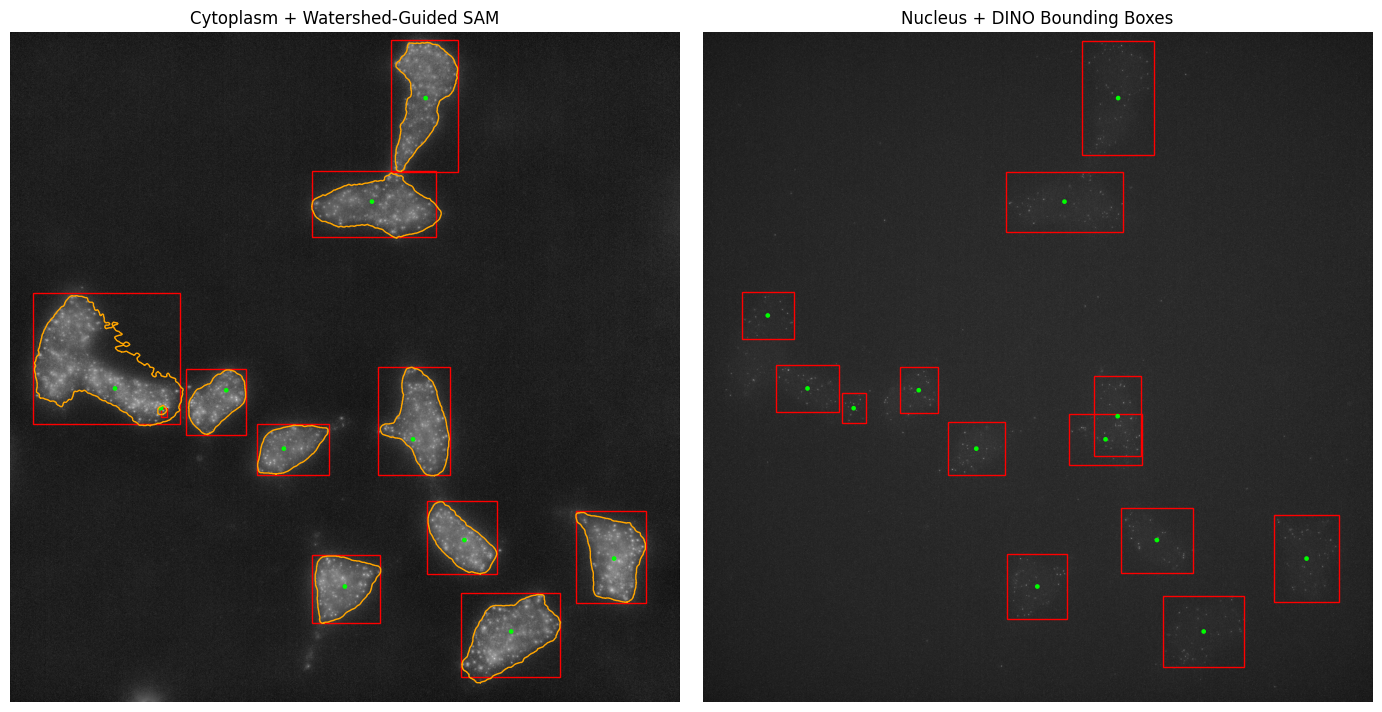

In [52]:
import cv2
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from skimage import filters, morphology, measure, segmentation
from scipy import ndimage as ndi
import pathlib

# --------------------------------------
# Helper functions
# --------------------------------------

def normalize_to_uint8(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def clahe_filter(img, clip_limit=4.0, tile_size=(8,8)):
    c = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return c.apply(img)

def gradient(channel, ksize=5):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    return cv2.morphologyEx(channel, cv2.MORPH_GRADIENT, kernel)

def postproc_mask(m):
    m = morphology.remove_small_objects(m.astype(bool), min_size=200)
    m = morphology.binary_closing(m, footprint=morphology.disk(3))
    m = morphology.binary_opening(m, footprint=morphology.disk(2))
    return m.astype(np.uint8)

def mask_to_bbox(mask):
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return (xs.min(), ys.min(), xs.max(), ys.max())

def watershed_segment_with_centers(cyt_img, centers):
    thresh = filters.threshold_otsu(cyt_img)
    binary = cyt_img > thresh
    binary = morphology.remove_small_holes(binary, area_threshold=1000)
    binary = morphology.remove_small_objects(binary, min_size=1000)
    dist = ndi.distance_transform_edt(binary)

    markers = np.zeros(cyt_img.shape, dtype=np.int32)
    for i, (cx, cy) in enumerate(centers, start=1):
        xi, yi = int(round(cx)), int(round(cy))
        if 0 <= yi < cyt_img.shape[0] and 0 <= xi < cyt_img.shape[1]:
            markers[yi, xi] = i

    edges = filters.sobel(cyt_img)
    elevation = -dist + 5 * edges
    labels = segmentation.watershed(elevation, markers=markers, mask=binary)

    masks = []
    for i in range(1, np.max(labels)+1):
        mask = (labels == i)
        if np.sum(mask) > 0:
            masks.append(postproc_mask(mask))
    return masks

# --------------------------------------
# Load image and preprocess
# --------------------------------------

image_path = pathlib.Path("C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/Composite Images (Multi-Channel)/488_pb5sp4_s1.composite.tif")

with tifffile.TiffFile(image_path) as tif:
    ch = tif.pages[0].asarray() # testing with 488
    nucleus = tif.pages[1].asarray()

ch = normalize_to_uint8(ch)

# ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
sigma_est = estimate_sigma(ch, channel_axis=-1, average_sigmas=True)
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

cyt_clahe = clahe_filter(ch)


# cyt_clahe = clahe_filter(ch)
# cyt_grad = gradient(clahe)

# ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
sigma_est = estimate_sigma(cyt_clahe, channel_axis=-1, average_sigmas=True)
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

sigma_norm = sigma_est + 3.0
sigma_weak = sigma_est - 10.0

cyt_bilat = cv2.bilateralFilter(cyt_clahe, d=9, sigmaColor=sigma_norm, sigmaSpace=15, borderType=cv2.BORDER_REFLECT_101)
cyt_edge_preserved = cv2.edgePreservingFilter(cyt_clahe, flags=1, sigma_s=sigma_norm, sigma_r=0.4)

cyt_grad = gradient(cyt_bilat)
cyt_bilat_edge = cv2.edgePreservingFilter(cyt_bilat, flags=1, sigma_s=sigma_weak, sigma_r=0.4)

laplacian = cv2.Laplacian(ch, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)
cyt_blended = cv2.addWeighted(cyt_bilat, 0.8, laplacian, 0.2, 0)

# --------
# Stacking
# --------
cyt_rgb = np.stack([cyt_blended, cyt_edge_preserved, cyt_bilat_edge], axis=-1)
bbox_nucleus = f.AppIntDINOwrapper(nucleus) 
centers = [((x1 + x2) / 2, (y1 + y2) / 2) for x1, y1, x2, y2 in bbox_nucleus]

# --- Creating Masks ---
masks_clahe = watershed_segment_with_centers(cyt_clahe, centers)
# masks_grad = watershed_segment(grad, centers)
masks_blended = watershed_segment_with_centers(cyt_blended, centers)
masks_bilat = watershed_segment(cyt_bilat, centers)
masks_edge_preserved = watershed_segment(cyt_edge_preserved, centers)
masks_bilat_edge = watershed_segment(cyt_bilat_edge, centers)

# --- Creating BBoxes ---
bbox_cyto = [mask_to_bbox(m) for m in masks_edge_preserved]
bbox_cyto = [b for b in bbox_cyto if b is not None]
bbox_cyto = [
    [float(x1), float(y1), float(x2), float(y2)] 
    for (x1, y1, x2, y2) in bbox_cyto
]


# -----------------------------
# SAM segmentation guided by boxes
# -----------------------------
masks_all = f.finetune.AppIntPREDICTCytoplasmWrapper(cyt_rgb, bbox_cyto)

masks = []
for mset in masks_all:
    areas = [(mm > 0).sum() for mm in mset]
    best = mset[np.argmax(areas)]
    masks.append(postproc_mask(best))

# --------------------------------------
# Visualization
# --------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Cytoplasm + masks
ax[0].imshow(cyt_clahe, cmap='gray')
ax[0].set_title("Cytoplasm + Watershed-Guided SAM")
ax[0].axis('off')
for (x1, y1, x2, y2), (cx, cy) in zip(bbox_cyto, centers):
    ax[0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', lw=1))
    ax[0].add_patch(Circle((cx, cy), radius=5, color='lime', fill=True))
for mask in masks:
    for contour in measure.find_contours(mask, 0.5):
        ax[0].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')

# Nucleus with bounding boxes
ax[1].imshow(nucleus, cmap='gray')
ax[1].set_title("Nucleus + DINO Bounding Boxes")
ax[1].axis('off')
for (x1, y1, x2, y2), (cx, cy) in zip(bbox_nucleus, centers):
    ax[1].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', lw=1))
    ax[1].add_patch(Circle((cx, cy), radius=5, color='lime', fill=True))

plt.tight_layout()
plt.show()